# Import Libraries 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')



# Dataset Loading

In [3]:
df = pd.read_csv("top_10_ai_stocks.csv", delimiter=',')
df['date'] = pd.to_datetime(df['date'])

#Pandas functions
print("df.info() :", df.info())
print("df.describe() :", df.describe())
print("df.columns :", df.columns)
print(df.isnull().sum())

# Use NVDA stock for analysis 
nvda_data = df[df['symbol'] == 'NVDA'].copy()
nvda_data = nvda_data.sort_values('date').reset_index(drop=True)
print(f"\nDataset Shape: {nvda_data.shape}")
print(f"Date Range: {nvda_data['date'].min()} to {nvda_data['date'].max()}")

# Use 'close' price as target
data = nvda_data['close'].values.reshape(-1, 1)

# Data Scaleing
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38736 entries, 0 to 38735
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   symbol    38736 non-null  object        
 1   date      38736 non-null  datetime64[ns]
 2   open      38736 non-null  float64       
 3   high      38736 non-null  float64       
 4   low       38736 non-null  float64       
 5   close     38736 non-null  float64       
 6   volume    38736 non-null  int64         
 7   adjusted  38736 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 2.4+ MB
df.info() : None
df.describe() :                                 date          open          high  \
count                          38736  38736.000000  38736.000000   
mean   2013-09-06 07:09:19.851300864     66.994416     68.051338   
min              1990-01-02 00:00:00      0.034896      0.035547   
25%              2008-04-18 00:00:00      4.12

# Numpy Operations

In [4]:
prices = nvda_data['close'].values

# np.diff - daily price change
daily_change = np.diff(prices)
print("Daily Price Changes (first 5):", daily_change[:5])

# Basic stats
print(f"\nNVDA Close Price Stats:")
print(f"  Mean   : {np.mean(prices):.2f}")
print(f"  Std Dev: {np.std(prices):.2f}")
print(f"  Min    : {np.min(prices):.2f}")
print(f"  Max    : {np.max(prices):.2f}")
p25, p50, p75 = np.percentile(prices, [25, 50, 75])
print(f"  25th % : {p25:.2f}")
print(f"  Median : {p50:.2f}")
print(f"  75th % : {p75:.2f}")

Daily Price Changes (first 5): [ 0.004297 -0.003516 -0.00013  -0.000131 -0.001953]

NVDA Close Price Stats:
  Mean   : 5.83
  Std Dev: 14.70
  Min    : 0.03
  Max    : 135.58
  25th % : 0.28
  Median : 0.46
  75th % : 4.13


# Seaborn Graphs

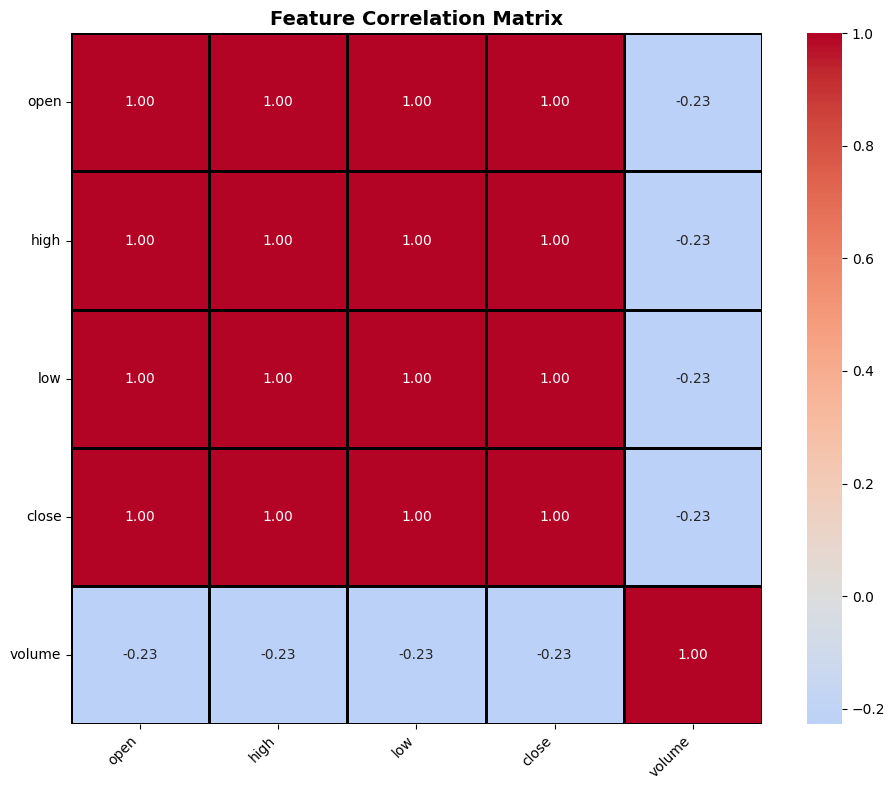

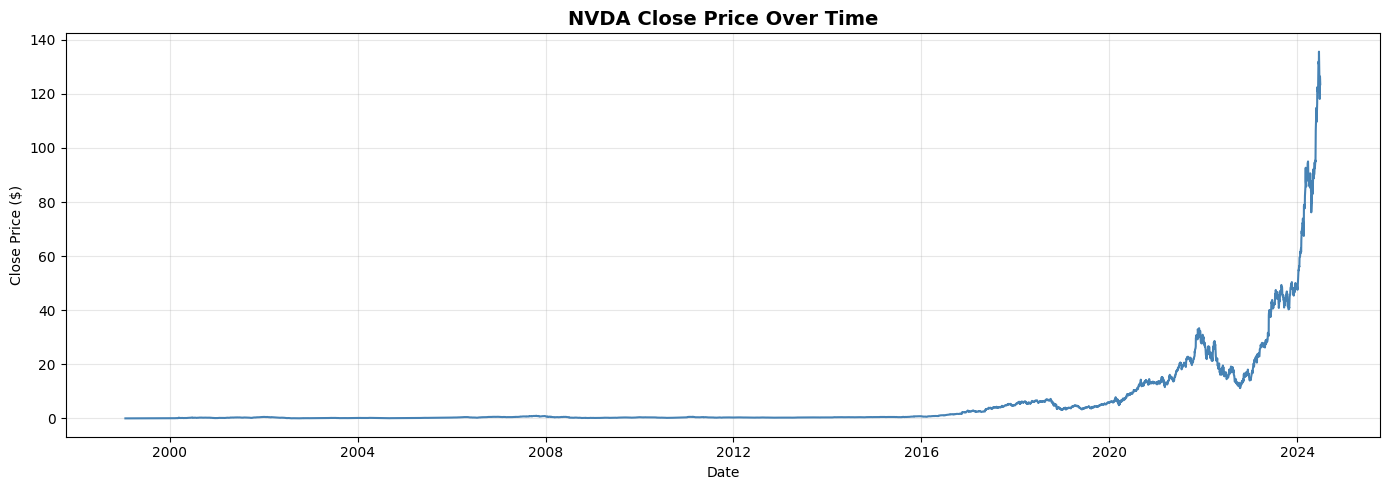

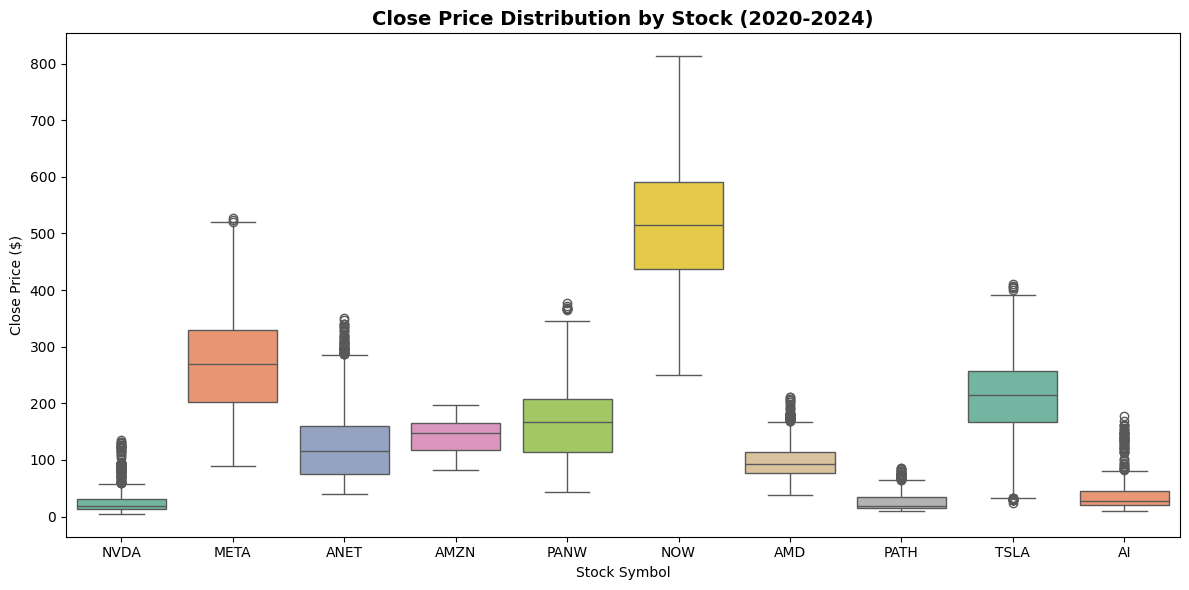

In [5]:
# Heatmap to show correlation 
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[["open", "high", "low", "close", "volume"]].corr(),  
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    linecolor='black',
    fmt='.2f'
)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Line Plot - NVDA Close Price Over Time
nvda_plot = df[df['symbol'] == 'NVDA'].copy()
plt.figure(figsize=(14, 5))
sns.lineplot(data=nvda_plot, x='date', y='close', color='steelblue', linewidth=1.5)
plt.title('NVDA Close Price Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Box Plot - Close Price Distribution by Symbol (last 4 years)
recent_df = df[df['date'] >= '2020-01-01']
plt.figure(figsize=(12, 6))
sns.boxplot(data=recent_df, x='symbol', y='close', palette='Set2')
plt.title('Close Price Distribution by Stock (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Stock Symbol')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()


# CREATE SEQUENCES FOR TIME SERIES

In [9]:
def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

TIME_STEPS = 60
X, y = create_sequences(scaled_data, TIME_STEPS)

# Reshape X for RNN/LSTM/GRU (samples, time steps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 5072
Testing samples: 1268


 # RNN MODEL

In [10]:
print("\n" + "="*50)
print("TRAINING RNN MODEL")
print("="*50)

rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    SimpleRNN(50),
    Dense(25, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()
rnn_history = rnn_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# RNN Predictions
rnn_pred = rnn_model.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred)
rnn_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# RNN Metrics
rnn_rmse = np.sqrt(mean_squared_error(rnn_actual, rnn_pred))
rnn_mae = mean_absolute_error(rnn_actual, rnn_pred)
rnn_r2 = r2_score(rnn_actual, rnn_pred)
rnn_mape = np.mean(np.abs((rnn_actual - rnn_pred) / rnn_actual)) * 100

print(f"\nRNN Results:")
print(f"  RMSE: {rnn_rmse:.2f}")
print(f"  MAE: {rnn_mae:.2f}")
print(f"  R² Score: {rnn_r2:.4f}")
print(f"  MAPE: {rnn_mape:.2f}%")


TRAINING RNN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,951 (34.96 KB)

 Trainable params: 8,951 (34.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3.0519e-04 - val_loss: 1.6700e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.2727e-06 - val_loss: 1.3559e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.0468e-06 - val_loss: 1.2023e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.3176e-06 - val_loss: 1.0830e-04
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.7819e-06 - val_loss: 8.9177e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.8662e-06 - val_loss: 7.1944e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2386e-06 - val_loss: 5.9193e-05
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.5851e-06 - val_loss: 5.0869e-05
Epoch 9/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.6480e-06 - val_loss: 3.9855e-05
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.8408e-06 - val_loss: 3.2285e-05
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/

 # LSTM MODEL

In [11]:
print("\n" + "="*50)
print("TRAINING LSTM MODEL")
print("="*50)

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()
lstm_history = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32,validation_split=0.1, verbose=1)

# LSTM Predictions
lstm_pred = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred)
lstm_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# LSTM Metrics
lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_pred))
lstm_mae = mean_absolute_error(lstm_actual, lstm_pred)
lstm_r2 = r2_score(lstm_actual, lstm_pred)
lstm_mape = np.mean(np.abs((lstm_actual - lstm_pred) / lstm_actual)) * 100

print(f"\nLSTM Results:")
print(f"  RMSE: {lstm_rmse:.2f}")
print(f"  MAE: {lstm_mae:.2f}")
print(f"  R² Score: {lstm_r2:.4f}")
print(f"  MAPE: {lstm_mape:.2f}%")


TRAINING LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 5.7830e-06 - val_loss: 7.4098e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 3.5841e-07 - val_loss: 5.8320e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 2.9258e-07 - val_loss: 4.9941e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 3.3094e-07 - val_loss: 4.5045e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.9816e-07 - val_loss: 5.1313e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 3.9044e-07 - val_loss: 4.2755e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 4.1052e-07 - val_loss: 5.1498e-05
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.0756e-07 - val_loss: 4.6197e-05
Epoch 9/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 2.2710e-07 - val_loss: 3.5937e-05
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 2.1231e-07 - val_loss: 3.4354e-05
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/

# GRU Model

In [12]:
print("\n" + "="*50)
print("TRAINING GRU MODEL")
print("="*50)

gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    GRU(50),
    Dense(25, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()
gru_history = gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# GRU Predictions
gru_pred = gru_model.predict(X_test)
gru_pred = scaler.inverse_transform(gru_pred)
gru_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# GRU Metrics
gru_rmse = np.sqrt(mean_squared_error(gru_actual, gru_pred))
gru_mae = mean_absolute_error(gru_actual, gru_pred)
gru_r2 = r2_score(gru_actual, gru_pred)
gru_mape = np.mean(np.abs((gru_actual - gru_pred) / gru_actual)) * 100

print(f"\nGRU Results:")
print(f"  RMSE: {gru_rmse:.2f}")
print(f"  MAE: {gru_mae:.2f}")
print(f"  R² Score: {gru_r2:.4f}")
print(f"  MAPE: {gru_mape:.2f}%")



TRAINING GRU MODEL


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 7.1100e-06 - val_loss: 1.1203e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 2.5058e-07 - val_loss: 9.7921e-06
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 3.0982e-07 - val_loss: 5.5648e-06
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 1.9767e-07 - val_loss: 5.6270e-06
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.2502e-07 - val_loss: 6.7119e-06
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.1939e-07 - val_loss: 6.3129e-06
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 3.8210e-07 - val_loss: 4.9365e-06
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.1894e-07 - val_loss: 5.6086e-06
Epoch 9/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.7775e-07 - val_loss: 5.4493e-06
Epoch 10/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 1.7142e-07 - val_loss: 3.8975e-06
Epoch 11/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/

# Findings

In [ ]:
# Model wise Analysis

# Simple RNN — R²: 84.24% — decent performance, captured short-term trends but struggled with long-term dependencies
# LSTM — R²: 64.47% — weakest performer on this dataset, higher error rate possibly due to overfitting on limited data
# GRU — R²: 96.03% — best performer, predicted stock prices with only 6.40% average error

# Observations

# GRU outperformed both RNN and LSTM significantly on this dataset
# LSTM underperformed compared to RNN — unusual but happens on smaller datasets
# GRU's simpler gating mechanism worked better than LSTM's complex architecture for this data

# Conclusion

# GRU is the best model for AI Stock Price prediction
# RNN second, LSTM third — GRU > RNN > LSTM
# Lower RMSE and MAE confirm GRU made closest predictions to actual prices
# 96% R² score shows GRU successfully learned the stock price trend patterns

# Model Comparison

In [20]:

print("MODEL COMPARISON SUMMARY")

comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'R² Score': [rnn_r2, lstm_r2, gru_r2],
    'MAPE (%)': [rnn_mape, lstm_mape, gru_mape]
})

print(comparison.to_string(index=False))


MODEL COMPARISON SUMMARY
Model      RMSE      MAE  R² Score  MAPE (%)
  RNN  9.620019 4.658706  0.842354 11.037924
 LSTM 14.441362 8.318410  0.644740 22.111500
  GRU  4.829710 2.306405  0.960265  6.402868


# Find best model

In [14]:
best_idx = comparison['RMSE'].idxmin()
print(f"\n Best Model: {comparison.loc[best_idx, 'Model']} (Lowest RMSE)")


 Best Model: GRU (Lowest RMSE)


# VISUALIZATION

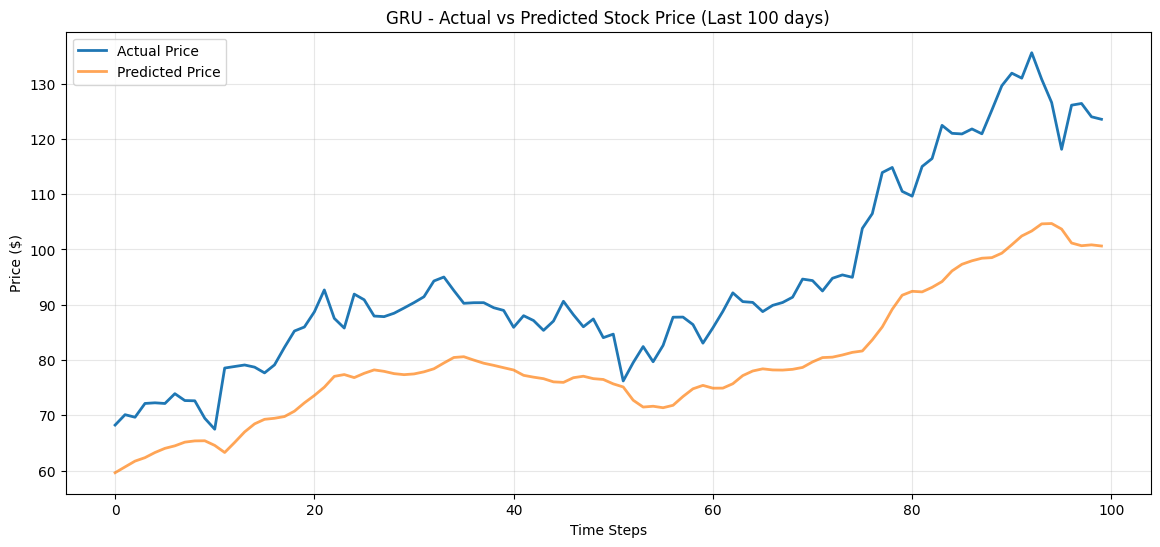

In [15]:

# Plot 1: Actual vs Predicted (Best Model)
plt.figure(figsize=(14, 6))

if best_idx == 0:
    best_pred, best_actual = rnn_pred, rnn_actual
    best_name = 'RNN'
elif best_idx == 1:
    best_pred, best_actual = lstm_pred, lstm_actual
    best_name = 'LSTM'
else:
    best_pred, best_actual = gru_pred, gru_actual
    best_name = 'GRU'

plt.plot(best_actual[-100:], label='Actual Price', linewidth=2)
plt.plot(best_pred[-100:], label='Predicted Price', linewidth=2, alpha=0.7)
plt.title(f'{best_name} - Actual vs Predicted Stock Price (Last 100 days)')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


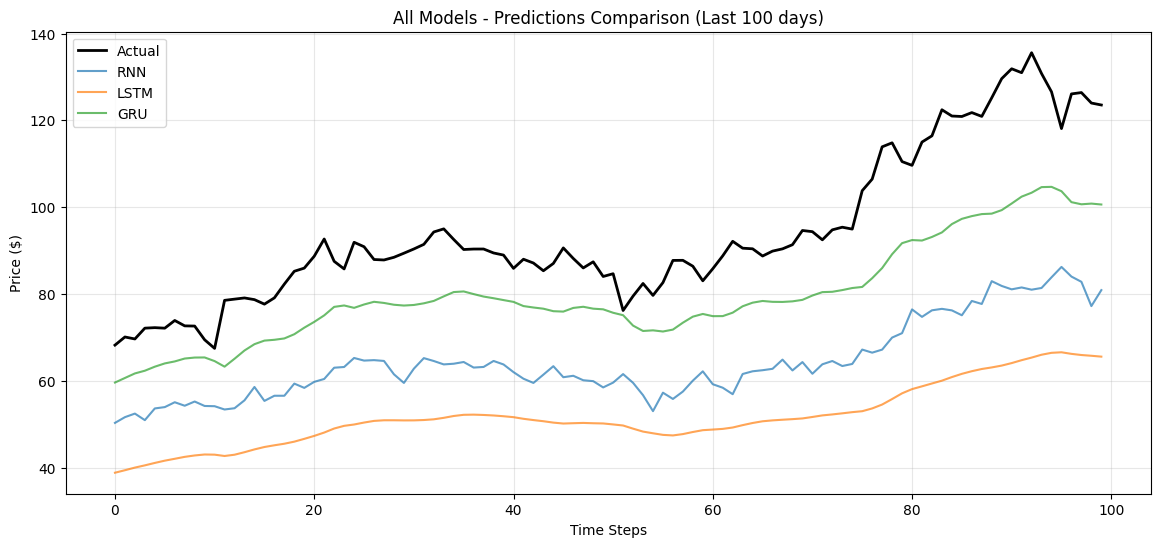

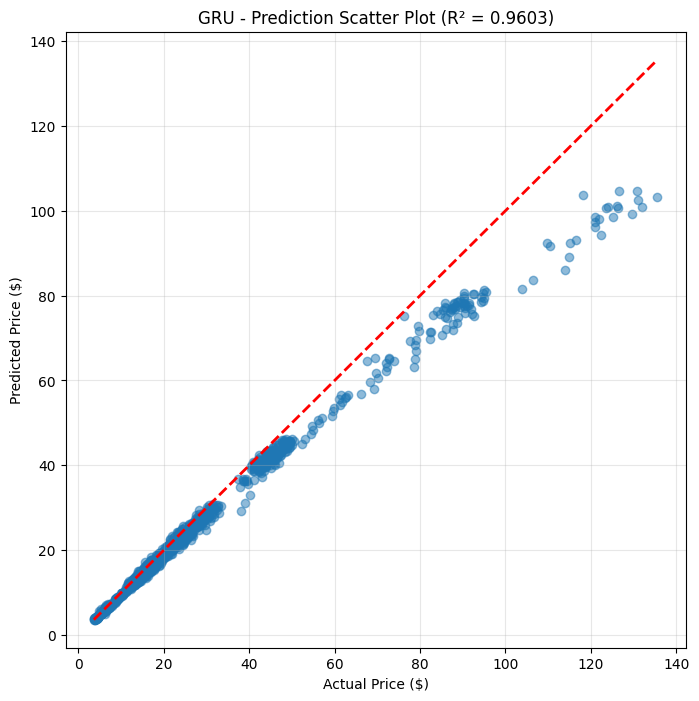

In [16]:
# Plot 3: All Models Comparison on Test Data
plt.figure(figsize=(14, 6))
plt.plot(rnn_actual[-100:], label='Actual', linewidth=2, color='black')
plt.plot(rnn_pred[-100:], label='RNN', alpha=0.7)
plt.plot(lstm_pred[-100:], label='LSTM', alpha=0.7)
plt.plot(gru_pred[-100:], label='GRU', alpha=0.7)
plt.title('All Models - Predictions Comparison (Last 100 days)')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Scatter Plot for Best Model
plt.figure(figsize=(8, 8))
plt.scatter(best_actual, best_pred, alpha=0.5)
plt.plot([best_actual.min(), best_actual.max()], 
         [best_actual.min(), best_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{best_name} - Prediction Scatter Plot (R² = {comparison.loc[best_idx, "R² Score"]:.4f})')
plt.grid(True, alpha=0.3)
plt.show()

# Additional Metrics

In [18]:

print("ADDITIONAL PERFORMANCE METRICS")


# Explained Variance Score
from sklearn.metrics import explained_variance_score

rnn_evs = explained_variance_score(rnn_actual, rnn_pred)
lstm_evs = explained_variance_score(lstm_actual, lstm_pred)
gru_evs = explained_variance_score(gru_actual, gru_pred)

print(f"\n2. Explained Variance Score (EVS):")
print(f"   RNN:  {rnn_evs:.4f}")
print(f"   LSTM: {lstm_evs:.4f}")
print(f"   GRU:  {gru_evs:.4f}")

#Maximum Error
rnn_max_error = np.max(np.abs(rnn_actual - rnn_pred))
lstm_max_error = np.max(np.abs(lstm_actual - lstm_pred))
gru_max_error = np.max(np.abs(gru_actual - gru_pred))

print(f"\n3. Maximum Error (Worst Prediction):")
print(f"   RNN:  {rnn_max_error:.2f}")
print(f"   LSTM: {lstm_max_error:.2f}")
print(f"   GRU:  {gru_max_error:.2f}")

#Median Absolute Error
rnn_medae = np.median(np.abs(rnn_actual - rnn_pred))
lstm_medae = np.median(np.abs(lstm_actual - lstm_pred))
gru_medae = np.median(np.abs(gru_actual - gru_pred))

print(f"\n4. Median Absolute Error (MedAE):")
print(f"   RNN:  {rnn_medae:.2f}")
print(f"   LSTM: {lstm_medae:.2f}")
print(f"   GRU:  {gru_medae:.2f}")

#Prediction Bias (Mean Error)
rnn_bias = np.mean(rnn_pred - rnn_actual)
lstm_bias = np.mean(lstm_pred - lstm_actual)
gru_bias = np.mean(gru_pred - gru_actual)

print(f"\n5. Prediction Bias (Positive = Overprediction):")
print(f"   RNN:  {rnn_bias:.2f}")
print(f"   LSTM: {lstm_bias:.2f}")
print(f"   GRU:  {gru_bias:.2f}")



ADDITIONAL PERFORMANCE METRICS

2. Explained Variance Score (EVS):
   RNN:  0.8770
   LSTM: 0.7618
   GRU:  0.9688

3. Maximum Error (Worst Prediction):
   RNN:  54.59
   LSTM: 70.23
   GRU:  32.25

4. Median Absolute Error (MedAE):
   RNN:  1.29
   LSTM: 3.92
   GRU:  0.89

5. Prediction Bias (Positive = Overprediction):
   RNN:  -4.51
   LSTM: -8.29
   GRU:  -2.24


# Training Loss Curve Plot

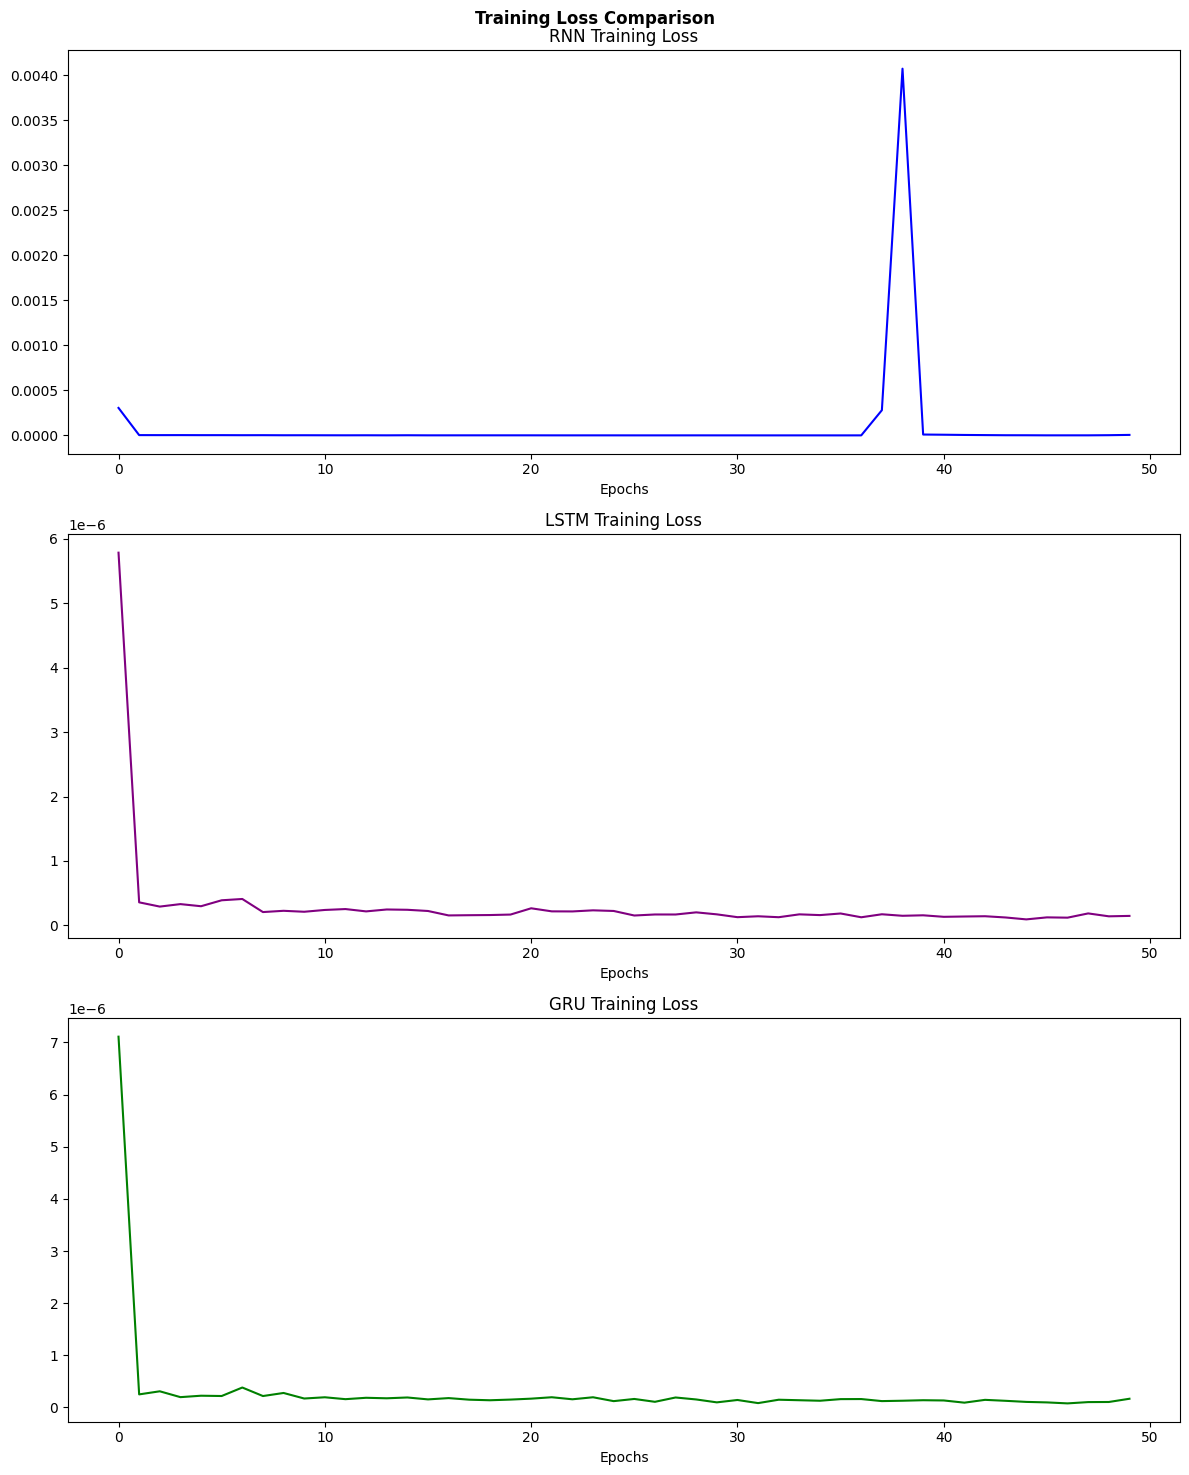

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15)) 

axes[0].plot(rnn_history.history['loss'], color='blue')
axes[0].set_title('RNN Training Loss')
axes[0].set_xlabel('Epochs')

axes[1].plot(lstm_history.history['loss'], color='purple')
axes[1].set_title('LSTM Training Loss')
axes[1].set_xlabel('Epochs')

axes[2].plot(gru_history.history['loss'], color='green')
axes[2].set_title('GRU Training Loss')
axes[2].set_xlabel('Epochs')

plt.suptitle('Training Loss Comparison', fontweight='bold')
plt.tight_layout()
plt.show()